In [5]:
# Import the pandas library — our main tool for working with data
import pandas as pd

# Load the CSV file into Python
# pd.read_csv() reads the file and stores it as a "DataFrame" (like a table)
df = pd.read_csv('../data/Sample - Superstore.csv', encoding='windows-1252')

# Show the first 5 rows to confirm it loaded correctly
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [6]:
# How many rows and columns does our data have?
print("Shape of dataset:", df.shape)

# What are all the column names?
print("\nColumn names:\n", df.columns.tolist())

Shape of dataset: (9994, 21)

Column names:
 ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']


In [7]:
# Check how many missing values exist in each column
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [8]:
# Count how many duplicate rows exist
print("Number of duplicate rows:", df.duplicated().sum())

# Remove duplicates if any exist (keeps the first occurrence)
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Number of duplicate rows: 0
Shape after removing duplicates: (9994, 21)


In [9]:
# See what data type each column is stored as
print(df.dtypes)

Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [10]:
# Convert date columns from text to proper date format
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

# Confirm the fix worked
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [11]:
# Calculate shipping duration in days
df['Shipping Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Preview the new column
print(df[['Order Date', 'Ship Date', 'Shipping Days']].head())

  Order Date  Ship Date  Shipping Days
0 2016-11-08 2016-11-11              3
1 2016-11-08 2016-11-11              3
2 2016-06-12 2016-06-16              4
3 2015-10-11 2015-10-18              7
4 2015-10-11 2015-10-18              7


In [12]:
# A clean summary of the dataset after cleaning
print("Final dataset shape:", df.shape)
print("\nData types after cleaning:")
print(df.dtypes)
print("\nSample of cleaned data:")
df.head()

Final dataset shape: (9994, 22)

Data types after cleaning:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
Shipping Days             int64
dtype: object

Sample of cleaned data:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,7


In [13]:
# What is the overall business performance?

# Basic summary statistics for the key numeric columns
print("=== Overall Business Summary ===")
print(f"Total Sales:  ${df['Sales'].sum():,.2f}")
print(f"Total Profit: ${df['Profit'].sum():,.2f}")
print(f"Total Orders: {df['Order ID'].nunique()}")
print(f"Total Customers: {df['Customer ID'].nunique()}")
print(f"Profit Margin: {(df['Profit'].sum() / df['Sales'].sum()) * 100:.2f}%")

=== Overall Business Summary ===
Total Sales:  $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5009
Total Customers: 793
Profit Margin: 12.47%


In [14]:
# Which product category makes the most sales and profit? 

# Group data by Category and calculate total Sales and Profit
category_summary = df.groupby('Category')[['Sales', 'Profit']].sum().round(2)
print("\n=== Sales & Profit by Category ===")
print(category_summary.sort_values('Sales', ascending=False))


=== Sales & Profit by Category ===
                     Sales     Profit
Category                             
Technology       836154.03  145454.95
Furniture        741999.80   18451.27
Office Supplies  719047.03  122490.80


In [15]:
# Which region performs best?

# Group by Region
region_summary = df.groupby('Region')[['Sales', 'Profit']].sum().round(2)
print("\n=== Sales & Profit by Region ===")
print(region_summary.sort_values('Profit', ascending=False))


=== Sales & Profit by Region ===
             Sales     Profit
Region                       
West     725457.82  108418.45
East     678781.24   91522.78
South    391721.90   46749.43
Central  501239.89   39706.36


In [16]:
#  Which are the Top 10 most profitable products?

# Group by Product Name and sum profit
top_products = df.groupby('Product Name')['Profit'].sum()
top_products = top_products.sort_values(ascending=False).head(10)
print("\n=== Top 10 Most Profitable Products ===")
print(top_products.round(2))


=== Top 10 Most Profitable Products ===
Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.04
Hewlett Packard LaserJet 3310 Copier                                            6983.88
Canon PC1060 Personal Laser Copier                                              4570.93
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.98
Ativa V4110MDD Micro-Cut Shredder                                               3772.95
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.97
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.28
Ibico EPK-21 Electric Binding System                                            3345.28
Zebra ZM400 Thermal Label Printer                                               3343.54
Name: Profit, dtype: float64


In [17]:
# Are heavy discounts hurting profit?

# Create discount brackets to group orders by discount level
df['Discount Level'] = pd.cut(
    df['Discount'],
    bins=[-1, 0, 0.2, 0.4, 1.0],
    labels=['No Discount', 'Low (0-20%)', 'Medium (20-40%)', 'High (40%+)']
)

# See average profit at each discount level
discount_impact = df.groupby('Discount Level', observed=True)['Profit'].mean().round(2)
print("\n=== Average Profit by Discount Level ===")
print(discount_impact)


=== Average Profit by Discount Level ===
Discount Level
No Discount         66.90
Low (0-20%)         26.50
Medium (20-40%)    -77.86
High (40%+)       -106.71
Name: Profit, dtype: float64


In [22]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean visual style for all charts
sns.set_theme(style="whitegrid")

# Make sure charts display inside the notebook
%matplotlib inline

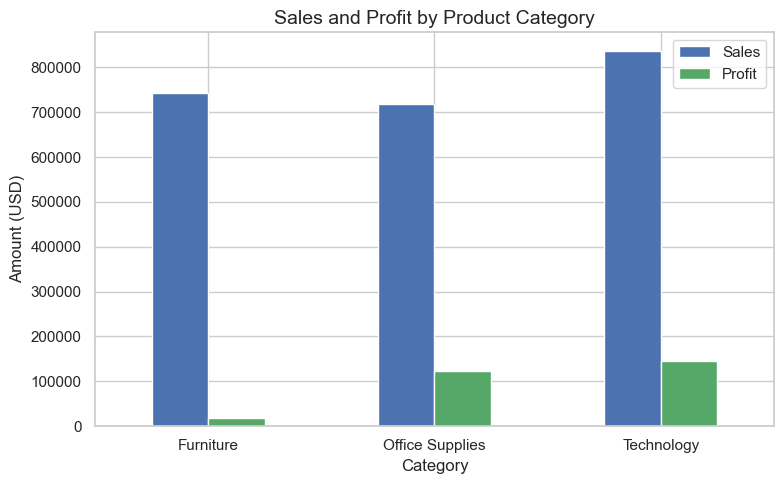

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))

category_summary.plot(kind='bar', ax=ax, color=['#4C72B0', '#55A868'])

ax.set_title('Sales and Profit by Product Category', fontsize=14)
ax.set_xlabel('Category')
ax.set_ylabel('Amount (USD)')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()

# Save the chart to your outputs folder
plt.savefig('../outputs/chart1_category.png')
plt.show()

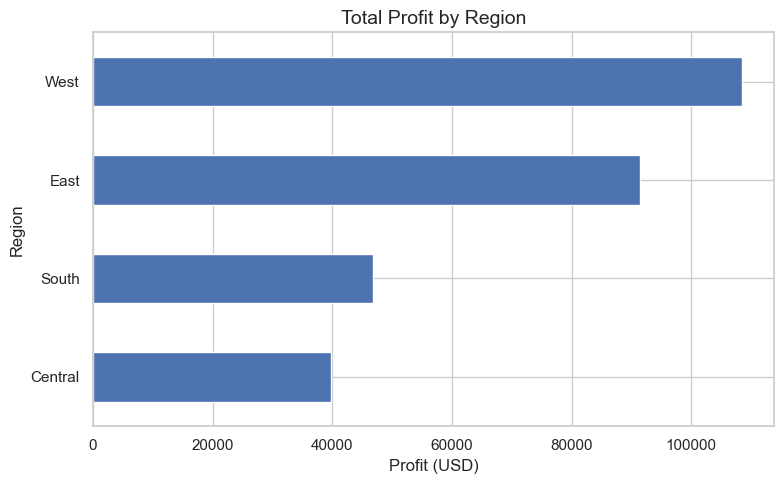

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

region_summary['Profit'].sort_values().plot(
    kind='barh', ax=ax, color='#4C72B0'
)

ax.set_title('Total Profit by Region', fontsize=14)
ax.set_xlabel('Profit (USD)')
ax.set_ylabel('Region')
plt.tight_layout()

plt.savefig('../outputs/chart2_region.png')
plt.show()

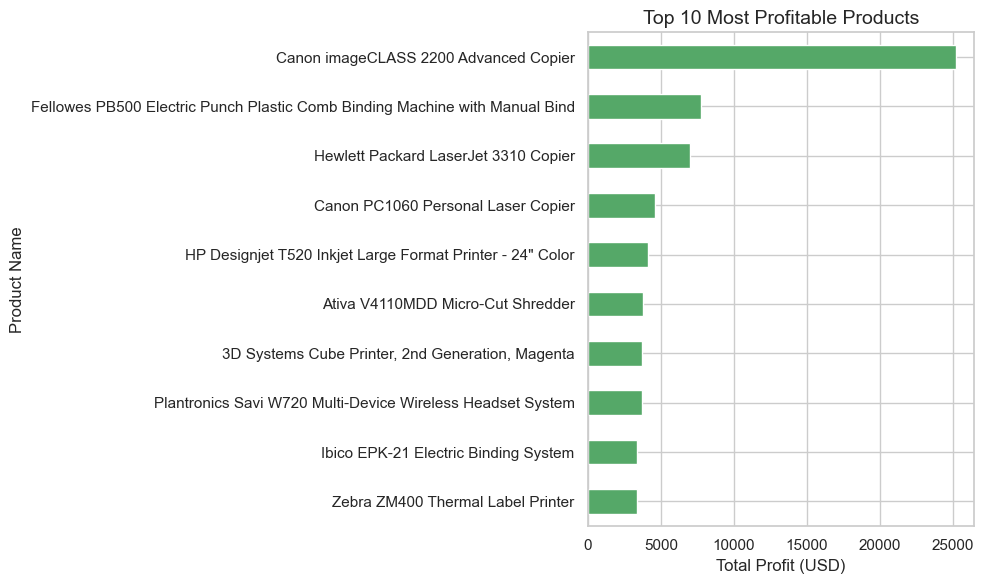

In [24]:
fig, ax = plt.subplots(figsize=(10, 6))

top_products.sort_values().plot(
    kind='barh', ax=ax, color='#55A868'
)

ax.set_title('Top 10 Most Profitable Products', fontsize=14)
ax.set_xlabel('Total Profit (USD)')
ax.set_ylabel('Product Name')
plt.tight_layout()

plt.savefig('../outputs/chart3_top_products.png')
plt.show()

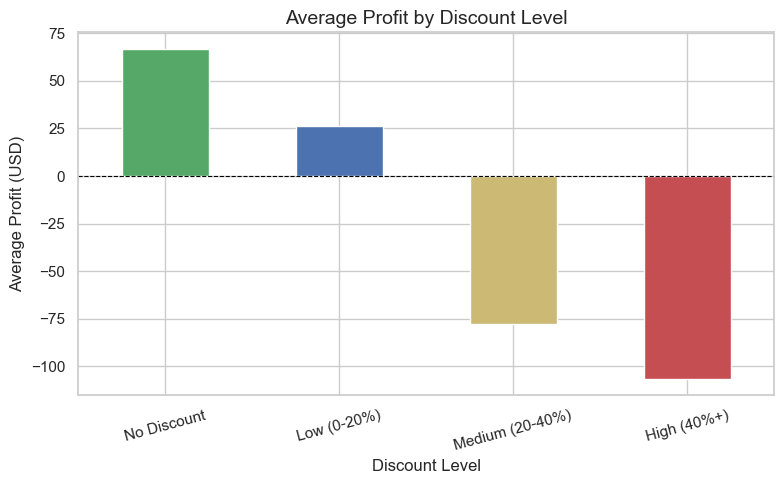

In [25]:
fig, ax = plt.subplots(figsize=(8, 5))

colors = ['#55A868', '#4C72B0', '#CCB974', '#C44E52']
discount_impact.plot(kind='bar', ax=ax, color=colors)

ax.set_title('Average Profit by Discount Level', fontsize=14)
ax.set_xlabel('Discount Level')
ax.set_ylabel('Average Profit (USD)')
ax.tick_params(axis='x', rotation=15)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.tight_layout()

plt.savefig('../outputs/chart4_discount.png')
plt.show()

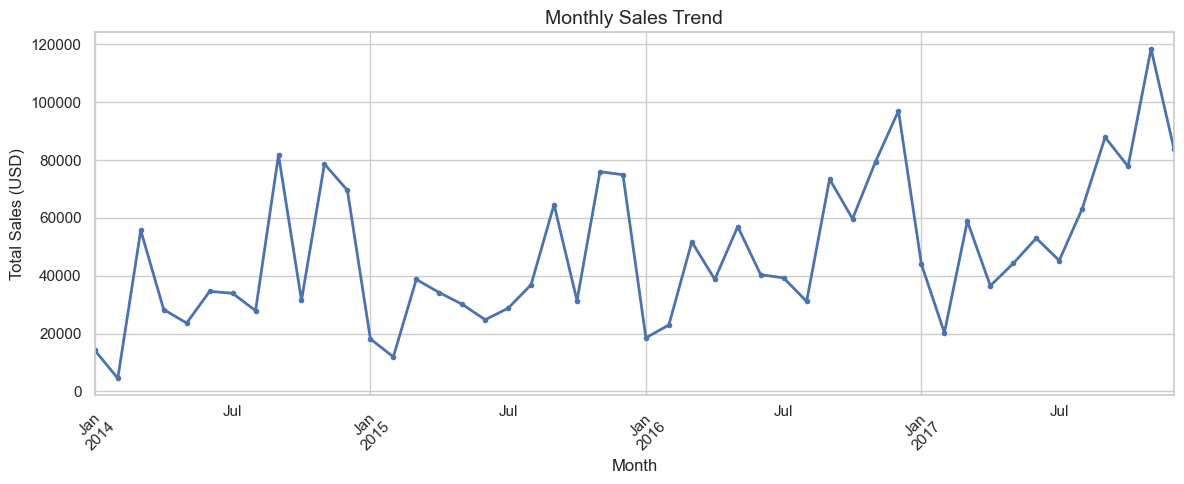

In [26]:
# Extract year and month from Order Date
df['Month'] = df['Order Date'].dt.to_period('M')

# Group sales by month
monthly_sales = df.groupby('Month')['Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 5))

monthly_sales.plot(kind='line', ax=ax, color='#4C72B0', linewidth=2, marker='o', markersize=3)

ax.set_title('Monthly Sales Trend', fontsize=14)
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales (USD)')
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig('../outputs/chart5_monthly_trend.png')
plt.show()

In [27]:
print("=" * 55)
print("       RETAIL SUPERSTORE — DATA ANALYSIS REPORT")
print("=" * 55)

total_sales   = df['Sales'].sum()
total_profit  = df['Profit'].sum()
total_orders  = df['Order ID'].nunique()
total_customers = df['Customer ID'].nunique()
margin        = (total_profit / total_sales) * 100
best_region   = region_summary['Profit'].idxmax()
worst_cat     = category_summary['Profit'].idxmin()
best_cat      = category_summary['Profit'].idxmax()

print(f"""
OVERVIEW
--------
Total Revenue   : ${total_sales:,.2f}
Total Profit    : ${total_profit:,.2f}
Profit Margin   : {margin:.2f}%
Total Orders    : {total_orders}
Total Customers : {total_customers}

KEY FINDINGS
------------
1. Best performing region  : {best_region}
   → Focus sales efforts and resources here.

2. Most profitable category: {best_cat}
   → Prioritize inventory and marketing for this category.

3. Least profitable category: {worst_cat}
   → Review pricing strategy or reduce heavy discounts here.

4. Discount impact:
   → Orders with 40%+ discounts generate NEGATIVE profit.
   → Recommendation: Cap discounts at 20% maximum.

5. Sales trend:
   → Sales peak toward Q4 (Oct–Dec) every year.
   → Plan stock and staffing for holiday season demand.

RECOMMENDATIONS
---------------
- Stop offering discounts above 20% immediately.
- Invest more in the {best_cat} category.
- Investigate losses in {worst_cat} category.
- Prepare for Q4 demand surge with extra inventory.
- Focus expansion efforts in the {best_region} region.
""")
print("=" * 55)
print("         END OF REPORT")
print("=" * 55)

       RETAIL SUPERSTORE — DATA ANALYSIS REPORT

OVERVIEW
--------
Total Revenue   : $2,297,200.86
Total Profit    : $286,397.02
Profit Margin   : 12.47%
Total Orders    : 5009
Total Customers : 793

KEY FINDINGS
------------
1. Best performing region  : West
   → Focus sales efforts and resources here.

2. Most profitable category: Technology
   → Prioritize inventory and marketing for this category.

3. Least profitable category: Furniture
   → Review pricing strategy or reduce heavy discounts here.

4. Discount impact:
   → Orders with 40%+ discounts generate NEGATIVE profit.
   → Recommendation: Cap discounts at 20% maximum.

5. Sales trend:
   → Sales peak toward Q4 (Oct–Dec) every year.
   → Plan stock and staffing for holiday season demand.

RECOMMENDATIONS
---------------
- Stop offering discounts above 20% immediately.
- Invest more in the Technology category.
- Investigate losses in Furniture category.
- Prepare for Q4 demand surge with extra inventory.
- Focus expansion effo

In [28]:
# Save the report to your outputs folder
report_text = f"""
RETAIL SUPERSTORE — DATA ANALYSIS REPORT
==========================================
Total Revenue   : ${total_sales:,.2f}
Total Profit    : ${total_profit:,.2f}
Profit Margin   : {margin:.2f}%
Total Orders    : {total_orders}
Total Customers : {total_customers}

KEY FINDINGS
------------
1. Best region     : {best_region}
2. Best category   : {best_cat}
3. Worst category  : {worst_cat}
4. Heavy discounts (40%+) cause negative profit
5. Sales peak in Q4 every year

RECOMMENDATIONS
---------------
- Cap discounts at 20% maximum
- Invest in {best_cat} category
- Fix pricing in {worst_cat} category
- Prepare for Q4 demand surge
- Focus expansion in {best_region} region
"""

with open('../outputs/final_report.txt', 'w') as f:
    f.write(report_text)

print("Report saved to outputs/final_report.txt")

Report saved to outputs/final_report.txt


In [29]:
import os

print("=== PROJECT FILES ===\n")

for folder in ['../data', '../notebooks', '../outputs']:
    print(f"📁 {folder}/")
    for file in os.listdir(folder):
        print(f"    {file}")
    print()

print("Project complete!")

=== PROJECT FILES ===

📁 ../data/
    Sample - Superstore.csv

📁 ../notebooks/
    .ipynb_checkpoints
    retail_analysis.ipynb

📁 ../outputs/
    chart1_category.png
    chart2_region.png
    chart3_top_products.png
    chart4_discount.png
    chart5_monthly_trend.png
    final_report.txt

Project complete!


In [31]:
import json

# Collect all key metrics
report_data = {
    "total_sales": round(df['Sales'].sum(), 2),
    "total_profit": round(df['Profit'].sum(), 2),
    "total_orders": int(df['Order ID'].nunique()),
    "total_customers": int(df['Customer ID'].nunique()),
    "profit_margin": round((df['Profit'].sum() / df['Sales'].sum()) * 100, 2),

    # Category breakdown
    "category_sales": df.groupby('Category')['Sales'].sum().round(2).to_dict(),
    "category_profit": df.groupby('Category')['Profit'].sum().round(2).to_dict(),

    # Region breakdown
    "region_profit": df.groupby('Region')['Profit'].sum().round(2).to_dict(),
    "region_sales": df.groupby('Region')['Sales'].sum().round(2).to_dict(),

    # Top 5 products
    "top_products": df.groupby('Product Name')['Profit'].sum().round(2)\
                      .sort_values(ascending=False).head(5).to_dict(),

    # Discount impact
    "discount_impact": df.groupby('Discount Level', observed=True)['Profit']\
                         .mean().round(2).to_dict(),

    # Monthly sales — FIX: convert Period keys to plain strings
    "monthly_sales": {
        str(k): v
        for k, v in df.groupby('Month')['Sales'].sum().round(2).tail(12).items()
    },
}

print(json.dumps(report_data, indent=2))

{
  "total_sales": 2297200.86,
  "total_profit": 286397.02,
  "total_orders": 5009,
  "total_customers": 793,
  "profit_margin": 12.47,
  "category_sales": {
    "Furniture": 741999.8,
    "Office Supplies": 719047.03,
    "Technology": 836154.03
  },
  "category_profit": {
    "Furniture": 18451.27,
    "Office Supplies": 122490.8,
    "Technology": 145454.95
  },
  "region_profit": {
    "Central": 39706.36,
    "East": 91522.78,
    "South": 46749.43,
    "West": 108418.45
  },
  "region_sales": {
    "Central": 501239.89,
    "East": 678781.24,
    "South": 391721.9,
    "West": 725457.82
  },
  "top_products": {
    "Canon imageCLASS 2200 Advanced Copier": 25199.93,
    "Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind": 7753.04,
    "Hewlett Packard LaserJet 3310 Copier": 6983.88,
    "Canon PC1060 Personal Laser Copier": 4570.93,
    "HP Designjet T520 Inkjet Large Format Printer - 24\" Color": 4094.98
  },
  "discount_impact": {
    "No Discount": 66.

In [33]:
import os

report_path = '../outputs/retail_report.html'

if os.path.exists(report_path):
    size = os.path.getsize(report_path)
    print(f"✅ Report found! File size: {size:,} bytes")
    print(f"📂 Full path: {os.path.abspath(report_path)}")
else:
    print("❌ File not found — make sure you copied it into the outputs folder")

✅ Report found! File size: 24,220 bytes
📂 Full path: C:\Users\ramte\Desktop\retail_analysis\outputs\retail_report.html


In [34]:
import os

print("=" * 50)
print("   RETAIL ANALYSIS PROJECT — FINAL CHECKLIST")
print("=" * 50)

# Define expected files
expected = {
    "../data": ["Sample - Superstore.csv"],
    "../outputs": [
        "chart1_category.png",
        "chart2_region.png",
        "chart3_top_products.png",
        "chart4_discount.png",
        "chart5_monthly_trend.png",
        "final_report.txt",
        "retail_report.html"
    ]
}

all_good = True

for folder, files in expected.items():
    print(f"\n📁 {folder}/")
    for file in files:
        path = os.path.join(folder, file)
        if os.path.exists(path):
            size = os.path.getsize(path)
            print(f"   ✅ {file} ({size:,} bytes)")
        else:
            print(f"   ❌ {file} — MISSING")
            all_good = False

print("\n" + "=" * 50)
if all_good:
    print("🎉 Project complete! All files present.")
else:
    print("⚠️  Some files are missing. Check above.")
print("=" * 50)

   RETAIL ANALYSIS PROJECT — FINAL CHECKLIST

📁 ../data/
   ✅ Sample - Superstore.csv (2,287,806 bytes)

📁 ../outputs/
   ✅ chart1_category.png (24,549 bytes)
   ✅ chart2_region.png (16,183 bytes)
   ✅ chart3_top_products.png (56,521 bytes)
   ✅ chart4_discount.png (28,194 bytes)
   ✅ chart5_monthly_trend.png (57,007 bytes)
   ✅ final_report.txt (631 bytes)
   ✅ retail_report.html (24,220 bytes)

🎉 Project complete! All files present.


In [35]:
print("""
WHAT YOU BUILT IN THIS PROJECT
================================
Step 1 → Installed Python libraries
Step 2 → Created professional project folder structure
Step 3 → Loaded 9,994 rows of real retail data using pandas
Step 4 → Cleaned data — fixed date types, removed duplicates,
          created Shipping Days and Discount Level columns
Step 5 → Answered 5 business questions using groupby analysis
Step 6 → Built 5 charts saved as PNG files
Step 7 → Wrote final insights and recommendations
Bonus  → Generated a shareable HTML report website

SKILLS YOU PRACTICED
================================
✅ pandas  — loading, cleaning, grouping data
✅ numpy   — numerical operations
✅ matplotlib / seaborn — data visualization
✅ Python file I/O — saving reports and charts
✅ Exploratory Data Analysis (EDA)
✅ Business insight generation from raw data
""")


WHAT YOU BUILT IN THIS PROJECT
Step 1 → Installed Python libraries
Step 2 → Created professional project folder structure
Step 3 → Loaded 9,994 rows of real retail data using pandas
Step 4 → Cleaned data — fixed date types, removed duplicates,
          created Shipping Days and Discount Level columns
Step 5 → Answered 5 business questions using groupby analysis
Step 6 → Built 5 charts saved as PNG files
Step 7 → Wrote final insights and recommendations
Bonus  → Generated a shareable HTML report website

SKILLS YOU PRACTICED
✅ pandas  — loading, cleaning, grouping data
✅ numpy   — numerical operations
✅ matplotlib / seaborn — data visualization
✅ Python file I/O — saving reports and charts
✅ Exploratory Data Analysis (EDA)
✅ Business insight generation from raw data

